In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # ('wxf8ey6n', 'SM (Lorenz,MN:0,ObsN:0.1)'): {},
    # ('rt0ct08c', 'SM (EM,VE)'): {},
    ('qo8vrk1a', 'SM (EM,VE)'): {},
    ('r9m8k0u1', 'FDM (Heun,OT,1)'): {},
    ('c4173853', 'FDM (Heun,OT,1000)'): {},
    # ('zt01isgd', 'FDM (Heun,VE)'): {},
    # ('7xjj0irr', 'FM (Heun,VE)'): {},
    # ('3i9d4xei', 'FM (Heun,VE,ObsScore)'): {},
    # ('milrekro', 'FM (Heun,VE,ObsScore,LSC:1)'): {},
    # ('y17ihr53', 'FM (Heun,OT)'): {},
    # ('1ccofu4x', 'FM (Heun,Var.Expld)'): {},
    # ('uddktup1', 'FM (Obs.Sample)'): {},
    # ('aaiadqy1', 'FM (Obs.Loss)'): {},
}

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('qo8vrk1a', 'SM (EM,VE)'): {'cfg': Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
                                          out_dir='/root/workspace/out/dafm',
                                          run_subdir='runs',
                                          prediction_filename='trajectories.parquet',
                                          device='cuda',
                                          alt_id='qo8vrk1a',
                                          rng_seed=2376999025,
                                          fit=True,
                                          id=5,
                                          dataset=DoubleWell(predicted_state_count=1000,
                                                             time_step_count=100,
                                                             time_step_count_drop_first=0,
                                                             time_step_size=0.1,
                                          

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 0
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'predicted_state_[0-9]+_dim_{dim}')]].mean(axis=1)

In [7]:
v['trajectories']

,times,true_state_dim_0,observation_dim_0,predicted_state_0_dim_0,predicted_state_1_dim_0,predicted_state_2_dim_0,predicted_state_3_dim_0,predicted_state_4_dim_0,predicted_state_5_dim_0,predicted_state_6_dim_0,...,predicted_state_991_dim_0,predicted_state_992_dim_0,predicted_state_993_dim_0,predicted_state_994_dim_0,predicted_state_995_dim_0,predicted_state_996_dim_0,predicted_state_997_dim_0,predicted_state_998_dim_0,predicted_state_999_dim_0,predicted_state_mean_0
0,0.000000,-1.008885,-1.037598,-1.127722,-0.959838,-1.092769,-0.876421,-1.186717,-1.234996,-0.794833,...,-0.702212,-0.905891,-0.716925,-0.907156,-0.855761,-1.138891,-0.882988,-1.350493,-0.680186,-1.001805
1,0.100000,-0.990047,-0.911333,-0.902616,-0.925911,-0.918837,-0.926839,-0.820246,-0.874286,-0.897460,...,-0.965093,-0.996921,-0.821428,-0.939147,-0.872173,-0.918092,-0.985426,-0.796385,-0.829853,-0.916150
2,0.200000,-0.963767,-0.811504,-0.841009,-0.730104,-0.982441,-0.830199,-1.039602,-0.683914,-0.726252,...,-0.856962,-1.105387,-0.894129,-0.744382,-0.816209,-1.012360,-0.831617,-0.813414,-0.809101,-0.822822
3,0.300000,-1.020289,-0.946174,-0.744370,-0.865986,-0.983946,-1.016488,-0.804581,-0.878343,-0.763632,...,-1.043919,-1.002635,-1.023501,-0.943707,-0.961419,-0.954258,-0.800159,-0.907450,-1.002223,-0.946821
4,0.400000,-1.034468,-0.936765,-0.935051,-0.907719,-1.016433,-0.917162,-0.811033,-0.850303,-1.064130,...,-0.888903,-0.905732,-0.895826,-0.882876,-0.967348,-0.923303,-1.150246,-1.077368,-0.965440,-0.938412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,9.600000,-0.861362,-0.609281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,9.700000,-0.984532,-0.911681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,9.800000,-0.970493,-1.089546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,9.900001,-0.920799,-0.907130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


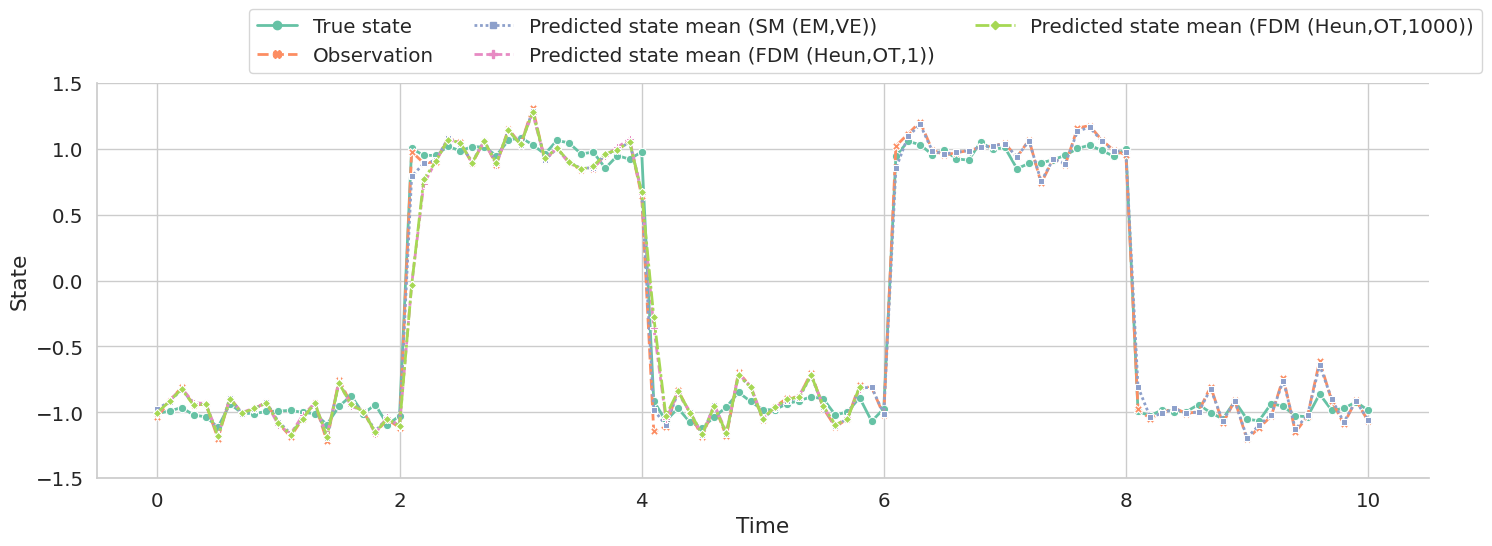

In [8]:
df_line = pd.concat([
    v['trajectories']['times'].rename('Time'),
    v['trajectories'][f'true_state_dim_{dim}'].rename('True state'),
    v['trajectories'][f'observation_dim_{dim}'].rename('Observation'),
    *(
        v['trajectories'][f'predicted_state_mean_{dim}'].rename(f'Predicted state mean ({k[1]})')
        for k, v in cfgs.items()
    )
], axis=1)
df_line_melt = df_line.melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=df_line_melt,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line_melt['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.12),
    frameon=True,
    fancybox=True,
)

In [9]:
df = df_line
print('RMSE')
print()
print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2))
print()
print('MAE')
df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean()
# (df.T - df['True state']).T.pow(2).sum()

RMSE

Time                                         5.787919
True state                                   0.000000
Observation                                  0.112803
Predicted state mean (SM (EM,VE))            0.105207
Predicted state mean (FDM (Heun,OT,1))       0.187614
Predicted state mean (FDM (Heun,OT,1000))    0.190446
dtype: float32

MAE


Time                                         5.000000
True state                                   0.000000
Observation                                  0.090422
Predicted state mean (SM (EM,VE))            0.084628
Predicted state mean (FDM (Heun,OT,1))       0.114776
Predicted state mean (FDM (Heun,OT,1000))    0.114001
dtype: float32

In [10]:
plots.save_all_subfigures(plot, 'Predictions')

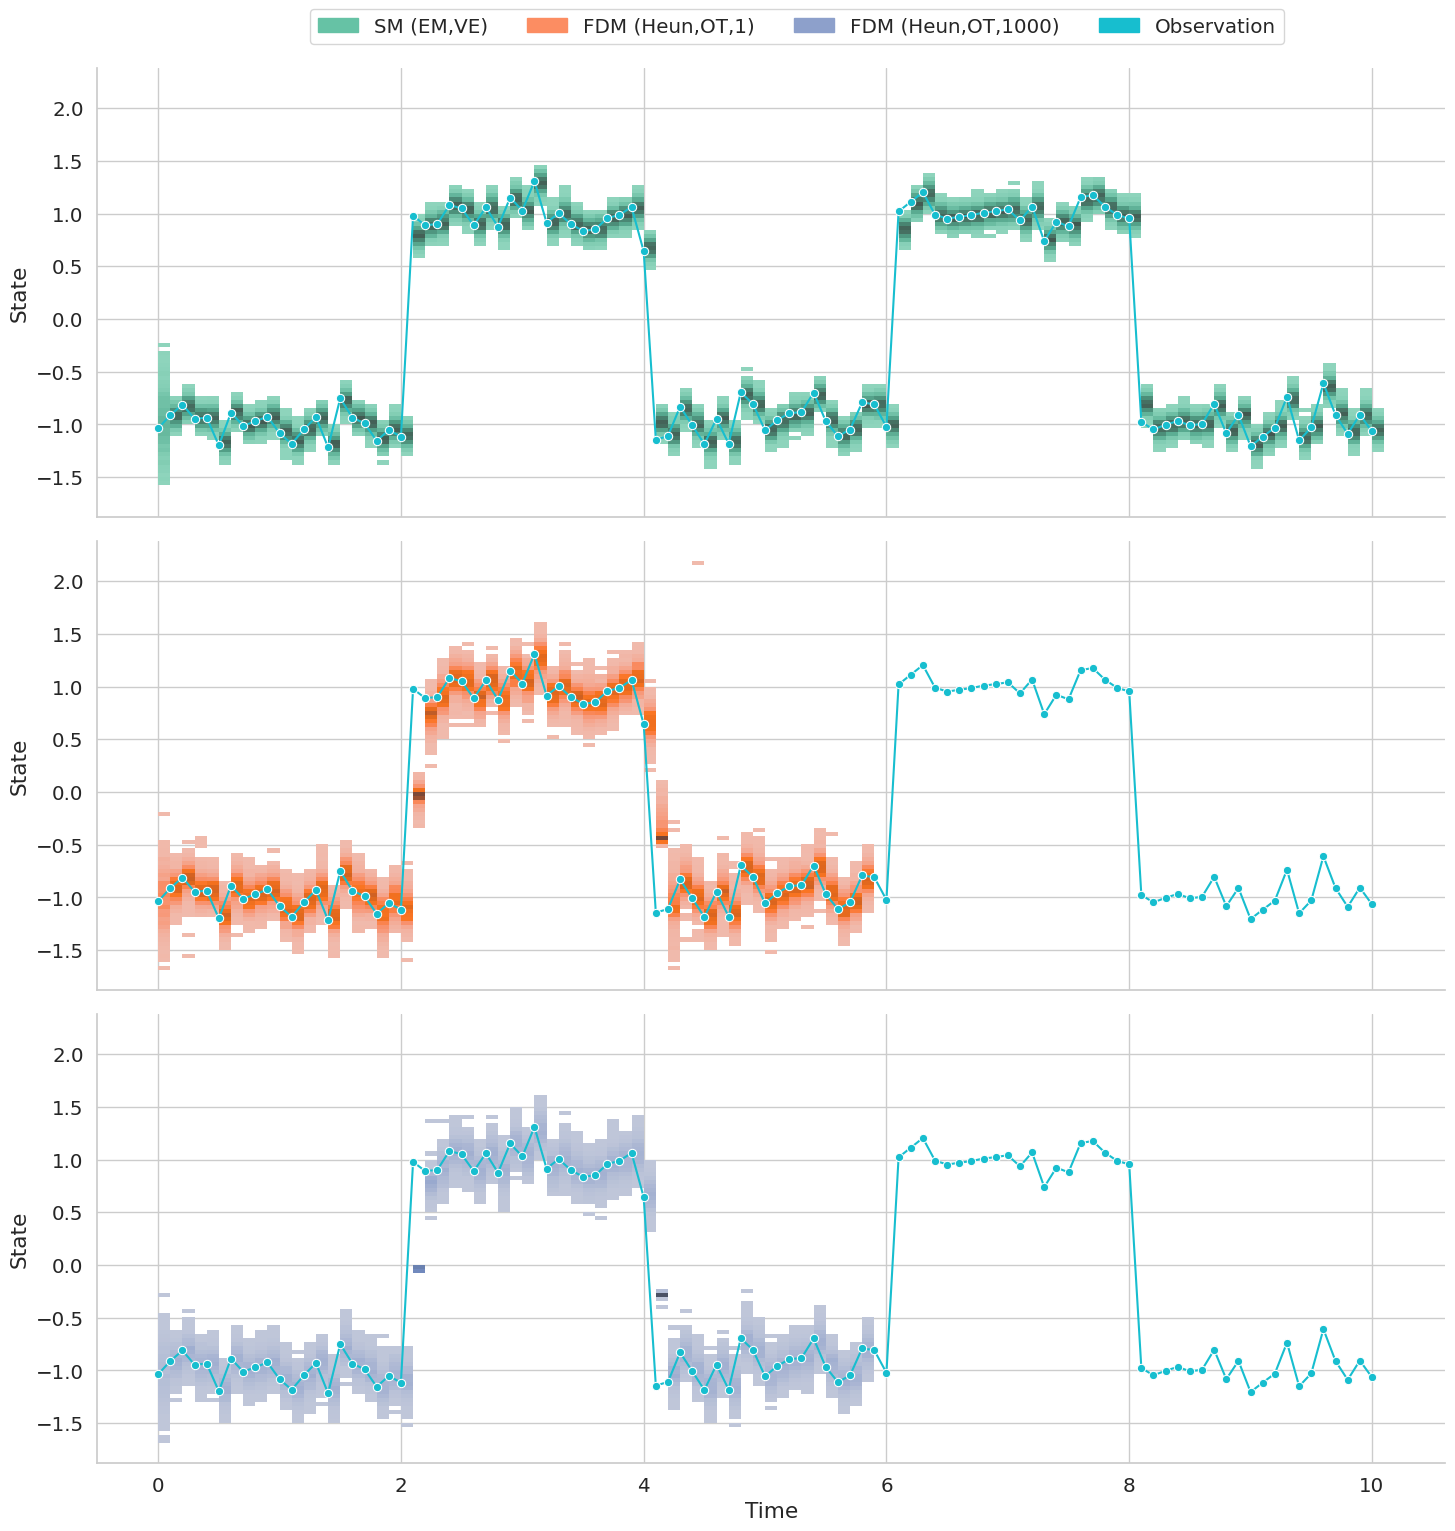

In [16]:
dim = 0
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')])
    .rename(columns={'times': 'Time'})
)
#.melt(id_vars=['Time'], var_name='Source', value_name='State')
df_hist
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=[*df_hist['Model'].unique(), 'Observation'],
        palette=[*sns.color_palette()[:len(df_hist['Model'].unique())], 'tab:cyan'],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        common_norm=False,
        # binrange=(None, (-3, 3)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=df_line_melt.loc[(df_line_melt['Source'] == 'Observation'), ['Time', 'State', 'Source']],
    x='Time',
    y='State',
    color='tab:cyan',
    style='Source',
    markers=True,
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(df_hist['Model'].unique()) + 1,
    title='',
    bbox_to_anchor=(.455, 1.03),
    frameon=True,
    fancybox=True,
)

In [12]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram')

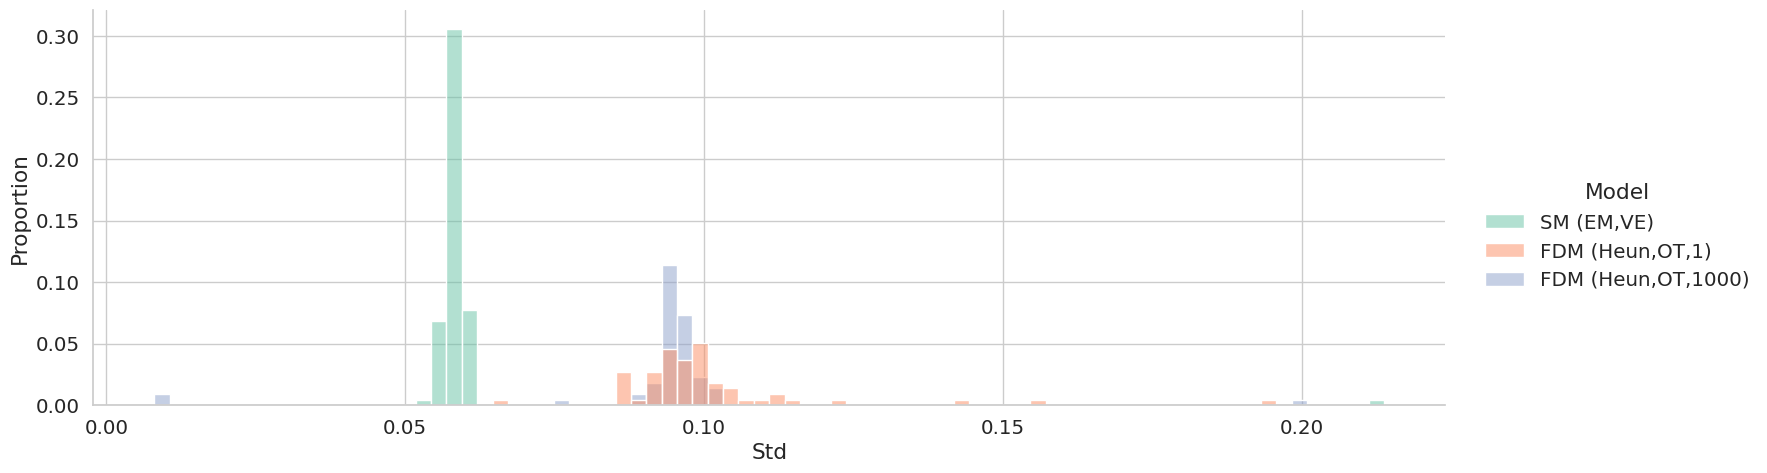

In [13]:
std = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1)
    .rename('Std')
    for k, v in cfgs.items()
], keys=[k[1] for k in cfgs], names=['Model']).reset_index()
plot = (
    sns.displot(
        data=std,
        x='Std',
        hue='Model',
        stat='proportion',
        aspect=3,
        bins=80,
    )
)
# plot.axes[0][0].set_xticks(np.arange(0, std['Std'].max() + .1, .1))
plot

In [14]:
std.loc[std['Model'] == 'FM (Obs.)']

,Model,level_1,Std


In [15]:
stats = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1, ddof=0)
    .describe()
    .rename(k[1])
    .to_frame().T
    for k, v in cfgs.items()
])
print(stats[stats.columns[stats.columns != 'count']].to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
SM (EM,VE) & 0.059709 & 0.015525 & 0.054286 & 0.057215 & 0.058219 & 0.059083 & 0.213639 \\
FDM (Heun,OT,1) & 0.100307 & 0.017665 & 0.066435 & 0.093299 & 0.096835 & 0.101122 & 0.194914 \\
FDM (Heun,OT,1000) & 0.093863 & 0.021348 & 0.008044 & 0.093358 & 0.095089 & 0.096984 & 0.198421 \\
\bottomrule
\end{tabular}

